# 🔥 Animal Faces Classification — Optimized, Documented & 5-Model Comparison

This is an optimized, deduplicated rewrite of `Animal_face_classification.ipynb`, extended into a small **model zoo**: 5 different architectures trained on the same data with the same reusable training code, so you can directly compare them.

Dataset: [Animal Faces (AFHQ)](https://www.kaggle.com/datasets/andrewmvd/animal-faces) — ~16k images across 3 classes (cat / dog / wildlife).

### What changed from your original notebook
- 🗑️ **Removed** dead code: unused variables, empty cells, duplicate imports, an unused `X`/`y` slice that was never referenced, and a `BATCH_SIZE` constant that was defined but silently ignored
- ⚡ **Optimized**: image-path collection via `glob` (was a 9-line triple-nested loop), a stratified `train_test_split` (was a manual `.sample()`/`.drop()` chain — and puts the already-imported-but-unused `train_test_split` to actual use), `BatchNorm2d` + `AdaptiveAvgPool2d` in every CNN (shrinks the classifier head from ~4.2 million parameters down to a few hundred, and removes the hard-coded flatten size), light train-only augmentation + `Normalize`
- ✅ **Completed**: the `test` split existed in your original code but was never actually evaluated on — wired up end-to-end. The `total_loss_train_plot` etc. lists were being collected every epoch but never plotted — now they are.
- 🧩 **One reusable `train_model()` + `evaluate()` function**, used for all 5 models, instead of duplicating a training loop per model — this is what keeps the "5 models" addition small in code, not 5× longer
- 🐘 **5 models, compared side by side**: a naive linear baseline, two from-scratch CNNs, and two pretrained (transfer-learning) backbones
- 📝 A markdown explanation + reference table before every code cell, and a full cheat-sheet at the end

> ⏱️ **Heads up on runtime:** training 5 models (2 of them deeper pretrained networks) takes meaningfully longer than training 1. `EPOCHS` is set to 5 by default to keep a full side-by-side comparison practical on a Colab GPU (roughly 15–25 min total on a T4) — bump it up once you've picked a winner.


---
## 1. Download the dataset

| Function | What it does |
|---|---|
| `opendatasets.download(url)` | downloads a Kaggle dataset; prompts for your Kaggle username + API key the first time |


In [1]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/andrewmvd/animal-faces")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: shravanvinayhegde
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/animal-faces


100%|██████████| 696M/696M [00:20<00:00, 35.7MB/s]


In [ ]:
#KGAT_cf50480c201d7bf73ba2aa32db48f7e1

## 2. Imports

Consolidated into one cell — the original had `torch`, `Dataset`/`DataLoader`, `matplotlib`, and `numpy` imported redundantly across four different cells, plus two unused imports (`sklearn.preprocessing` module and, until now, `train_test_split`).

| Import | Purpose |
|---|---|
| `torch`, `nn`, `torch.optim` | tensors, model building blocks, optimizers |
| `torchvision.transforms` | image preprocessing/augmentation pipeline |
| `torchvision.models` (`resnet18`, `mobilenet_v2`, + their `Weights` enums) | pretrained backbones for transfer learning |
| `torch.utils.data.Dataset, DataLoader` | data pipeline |
| `sklearn.preprocessing.LabelEncoder` | maps string labels (`"cat"`) → integers (`0`) |
| `sklearn.model_selection.train_test_split` | splits a DataFrame into subsets |
| `glob`, `os` | filesystem path discovery |
| `time` | timing each model's training run for the comparison table |
| `PIL.Image`, `pandas`, `numpy`, `matplotlib.pyplot` | image loading, tabular data, array math, plotting |


In [2]:
import glob
import os
import time

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights, mobilenet_v2, MobileNet_V2_Weights

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from PIL import Image
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 3. Device & hyperparameters

> **🔧 Fixed:** moved hyperparameters to the top, before anything that uses them (originally `BATCH_SIZE` was defined in a cell *after* the `DataLoader`s were already created with a different, hard-coded batch size — so it was silently never actually used). `LR` is also lowered from `0.01` to the much more conventional `1e-3` for Adam — `0.01` is on the high side and can cause unstable training, especially for the frozen-backbone transfer-learning models later on.

| Function | What it does |
|---|---|
| `torch.cuda.is_available()` | `True` if a CUDA GPU is visible to PyTorch |


In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device available:", device)

IMG_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 12      # kept small so all 5 models finish training in a reasonable time; increase once you've picked a winner
LR = 1e-3
NUM_CLASSES = 3

Device available: cuda


---
## 4. Collect image paths & labels

> **🔧 Optimized:** the original used a 9-line triple-nested `os.listdir` loop to walk `root/{split}/{label}/{file}`. `glob` does the exact same directory walk in 2 lines.

| Function | What it does |
|---|---|
| `glob.glob(pattern)` | returns every filesystem path matching a wildcard pattern — here, `*/*/*` matches exactly 3 levels deep (`{split}/{label}/{filename}`) |
| `path.split(os.sep)[-2]` | grabs the second-to-last path segment — the label folder's name |


In [4]:
data_root = "/content/animal-faces/afhq"
image_paths = glob.glob(f"{data_root}/*/*/*")           # root/{train,val}/{label}/{filename}
labels = [p.split(os.sep)[-2] for p in image_paths]      # label = parent folder name

data_df = pd.DataFrame({"image_paths": image_paths, "labels": labels})
print(data_df.shape)
data_df.head()

(16130, 2)


,image_paths,labels
0,/content/animal-faces/afhq/train/cat/flickr_ca...,cat
1,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
2,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
3,/content/animal-faces/afhq/train/cat/pixabay_c...,cat
4,/content/animal-faces/afhq/train/cat/pixabay_c...,cat


## 5. Drop missing rows

> **🔧 Removed:** the original also had `df = data_df.copy()` and a full-dataset `.sample(frac=1)` shuffle in a separate cell — `df` was never used again anywhere (dead code), and the shuffle was redundant since the split in the next section re-shuffles anyway. Both removed.


In [5]:
data_df = data_df.dropna().reset_index(drop=True)
data_df.shape

(16130, 2)

## 6. Stratified train / validation / test split

> **🔧 Optimized:** replaced the manual `.sample(frac=0.7)` → `.drop()` → `.sample(frac=0.5)` → `.drop()` chain with `train_test_split` — shorter, and it was already imported but unused. Added `stratify=`, which guarantees each split has the same class proportions as the full dataset (the manual random-sample approach didn't guarantee this).

| Function | Signature | What it does |
|---|---|---|
| `train_test_split(df, test_size, random_state, stratify)` | from `sklearn.model_selection` | splits a DataFrame; `stratify=col` keeps class proportions consistent across the split |


In [6]:
train, temp = train_test_split(data_df, test_size=0.3, random_state=7, stratify=data_df["labels"])
val, test = train_test_split(temp, test_size=0.5, random_state=7, stratify=temp["labels"])

train = train.reset_index(drop=True)
val = val.reset_index(drop=True)
test = test.reset_index(drop=True)

len(train), len(val), len(test)

(11291, 2419, 2420)

## 7. Label encoding & image transforms

> **🔧 Optimized:** added `transforms.Normalize` (standard ImageNet stats — helps training converge, and required for the pretrained models later to see inputs in the range they were trained on) and a **separate** training-only transform with `RandomHorizontalFlip` (a cheap, standard way to reduce overfitting; not applied to validation/test, since we want those to reflect real, unaugmented images).

| Class | What it does |
|---|---|
| `LabelEncoder` | maps string labels ↔ integer indices |
| `transforms.Compose([...])` | chains preprocessing steps into one callable |
| `transforms.Resize((h, w))` | resizes every image to the same fixed size |
| `transforms.RandomHorizontalFlip()` | 50% chance of a left-right flip — training only |
| `transforms.ToTensor()` | PIL image → tensor, scaled to `[0, 1]` |
| `transforms.Normalize(mean, std)` | per-channel standardization |


In [7]:
label_encoder = LabelEncoder()
label_encoder.fit(data_df["labels"])

IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

---
## 8. `Dataset` class & `DataLoader`s

The custom `Dataset` itself was already correct in your original notebook — kept as-is (just tidied the comments, which referenced internal Colab cell IDs from a previous AI edit).

> **🔧 Fixed:** DataLoaders now use the `BATCH_SIZE` constant (previously hard-coded to `32`, ignoring the separately-defined `BATCH_SIZE = 16`), and a **test** loader is added — the test split existed in the original but was never wrapped in a `Dataset`/`DataLoader` or evaluated on at all.

| Class / method | What it does |
|---|---|
| `Dataset.__len__` / `__getitem__` | the two methods `DataLoader` needs — "how many samples" and "give me sample `i`" |
| `DataLoader(dataset, batch_size, shuffle, num_workers, pin_memory)` | batches a `Dataset`; `num_workers>0` loads images in parallel subprocesses; `pin_memory=True` speeds up the CPU→GPU transfer |


In [8]:
class AnimalFacesDataset(Dataset):
    def __init__(self, dataframe, transform, label_encoder):
        self.dataframe = dataframe
        self.transform = transform
        self.label_encoder = label_encoder

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]["image_paths"]
        image = Image.open(img_path).convert("RGB")  # force RGB for consistency
        label = self.label_encoder.transform([self.dataframe.iloc[idx]["labels"]])[0]

        image = self.transform(image)
        label = torch.tensor(label, dtype=torch.long)
        return image, label


train_ds = AnimalFacesDataset(train, train_transform, label_encoder)
val_ds = AnimalFacesDataset(val, eval_transform, label_encoder)
test_ds = AnimalFacesDataset(test, eval_transform, label_encoder)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

## 9. Sanity-check: view a sample batch

| Function | What it does |
|---|---|
| `next(iter(loader))` | pulls one batch out of a `DataLoader` |
| `label_encoder.inverse_transform([i])` | integer label → original string (`0` → `"cat"`) |


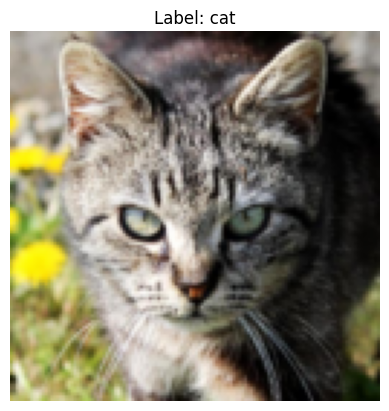

In [9]:
images, sample_labels = next(iter(train_loader))

# Undo normalization just for display purposes
img = images[0].numpy().transpose(1, 2, 0)
img = np.clip(img * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

plt.imshow(img)
plt.title(f"Label: {label_encoder.inverse_transform([sample_labels[0].item()])[0]}")
plt.axis("off")
plt.show()

---
## 10. The model zoo — 5 architectures

A shared `conv_block()` helper avoids writing out `Conv2d → BatchNorm2d → ReLU → MaxPool2d` by hand for every block — it's used 3 times in `SimpleCNN` and 4 times in `DeepCNN`, so defining it once saves duplicating that same 4-line pattern 7 times over.

| Class | What it does |
|---|---|
| `nn.Conv2d(in, out, kernel_size, padding)` | learns `out` filters that slide over the image, detecting local patterns (edges, textures, shapes) |
| `nn.BatchNorm2d(channels)` | normalizes activations per-channel — speeds up and stabilizes training |
| `nn.MaxPool2d(k)` | halves spatial resolution by taking the max over each `k×k` window — cheap way to shrink feature maps and gain translation-tolerance |
| `nn.AdaptiveAvgPool2d(1)` | averages each channel down to a single number, regardless of input resolution — this is what lets the classifier head use a small, fixed-size `Linear` layer instead of one sized to a specific image resolution |
| `nn.Dropout(p)` | randomly zeroes `p` fraction of activations during training — a regularizer that reduces overfitting |
| `nn.Flatten()` | collapses everything after the batch dimension into one vector |


In [10]:
def conv_block(in_channels, out_channels):
    return nn.Sequential(
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True),
        nn.MaxPool2d(2),
    )


class LogisticBaseline(nn.Module):
    """A single Linear layer on flattened pixels -- the simplest possible baseline, no convolutions at all."""
    def __init__(self, num_classes, img_size):
        super().__init__()
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(3 * img_size * img_size, num_classes))

    def forward(self, x):
        return self.net(x)


class SimpleCNN(nn.Module):
    """3 conv blocks. This is your original architecture, optimized with BatchNorm + global average pooling."""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Linear(128, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


class DeepCNN(nn.Module):
    """4 conv blocks + dropout -- more capacity, more regularization. Is deeper actually better here?"""
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            conv_block(3, 32), conv_block(32, 64), conv_block(64, 128), conv_block(128, 256),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, num_classes))

    def forward(self, x):
        return self.classifier(self.features(x))


def build_resnet18(num_classes):
    """ImageNet-pretrained ResNet18 with a frozen backbone -- only the new final layer trains."""
    model = resnet18(weights=ResNet18_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, num_classes)  # replacing fc makes it trainable again
    return model


def build_mobilenet(num_classes):
    """ImageNet-pretrained MobileNetV2 with a frozen backbone -- much smaller/faster than ResNet18."""
    model = mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)
    for param in model.parameters():
        param.requires_grad = False
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model


# name -> a zero-arg function that builds a fresh instance of that model
model_builders = {
    "Logistic Baseline": lambda: LogisticBaseline(NUM_CLASSES, IMG_SIZE),
    "Simple CNN":         lambda: SimpleCNN(NUM_CLASSES),
    "Deep CNN":            lambda: DeepCNN(NUM_CLASSES),
    "ResNet18 (transfer)": lambda: build_resnet18(NUM_CLASSES),
    "MobileNetV2 (transfer)": lambda: build_mobilenet(NUM_CLASSES),
}

---
## 11. One reusable training loop for every model

Rather than writing (and maintaining) five near-identical copy-pasted training loops, `train_model()` takes any model and trains/validates it — this is the key piece of "optimized, small code" here: adding a 6th model later only means adding one entry to `model_builders` above, not another 40-line loop.

| Function | What it does |
|---|---|
| `filter(function, iterable)` | built-in Python — keeps only the items where `function(item)` is `True`; used here to pass only *trainable* parameters to the optimizer (frozen backbone params are skipped) |
| `preds.argmax(1)` | index of the highest-scoring class per sample — the predicted class |
| `time.time()` | current timestamp in seconds, used to measure elapsed training time |


In [11]:
def train_model(model, name, train_loader, val_loader, epochs=EPOCHS, lr=LR):
    model.to(device)
    loss_fn = nn.CrossEntropyLoss()
    trainable_params = filter(lambda p: p.requires_grad, model.parameters())
    optimizer = torch.optim.Adam(trainable_params, lr=lr)

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        total_loss, total_correct = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            preds = model(inputs)
            loss = loss_fn(preds, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_correct += (preds.argmax(1) == labels).sum().item()

        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                preds = model(inputs)
                val_loss += loss_fn(preds, labels).item()
                val_correct += (preds.argmax(1) == labels).sum().item()

        history["train_loss"].append(total_loss / len(train_loader))
        history["val_loss"].append(val_loss / len(val_loader))
        history["train_acc"].append(total_correct / len(train_loader.dataset) * 100)
        history["val_acc"].append(val_correct / len(val_loader.dataset) * 100)

        print(f"[{name}] Epoch {epoch+1}/{epochs} | "
              f"Train Acc {history['train_acc'][-1]:.1f}% | Val Acc {history['val_acc'][-1]:.1f}%")

    elapsed = time.time() - start_time
    return history, elapsed


def evaluate(model, loader):
    """Runs a trained model over a DataLoader once, with no gradient tracking, and returns accuracy (%)."""
    model.eval()
    correct = 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs)
            correct += (preds.argmax(1) == labels).sum().item()
    return correct / len(loader.dataset) * 100

---
## 12. Train & evaluate all 5 models

This loops through `model_builders`, training each one with the *same* `train_model()` function, then scores it once on the untouched test set.


In [12]:
results = {}

for name, build_fn in model_builders.items():
    print("=" * 60)
    print(f"Training: {name}")
    model = build_fn()

    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    history, elapsed = train_model(model, name, train_loader, val_loader)
    test_acc = evaluate(model, test_loader)

    results[name] = {
        "history": history,
        "test_acc": test_acc,
        "train_time_sec": elapsed,
        "trainable_params": n_params,
    }
    print(f"-> {name}: Test Accuracy = {test_acc:.2f}% | Trainable params = {n_params:,} | Time = {elapsed:.1f}s")

Training: Logistic Baseline
[Logistic Baseline] Epoch 1/12 | Train Acc 66.1% | Val Acc 72.5%
[Logistic Baseline] Epoch 2/12 | Train Acc 71.7% | Val Acc 66.5%
[Logistic Baseline] Epoch 3/12 | Train Acc 72.5% | Val Acc 69.7%
[Logistic Baseline] Epoch 4/12 | Train Acc 74.1% | Val Acc 73.0%
[Logistic Baseline] Epoch 5/12 | Train Acc 75.2% | Val Acc 69.0%
[Logistic Baseline] Epoch 6/12 | Train Acc 75.9% | Val Acc 70.9%
[Logistic Baseline] Epoch 7/12 | Train Acc 76.1% | Val Acc 74.8%
[Logistic Baseline] Epoch 8/12 | Train Acc 76.5% | Val Acc 73.9%
[Logistic Baseline] Epoch 9/12 | Train Acc 77.1% | Val Acc 75.5%
[Logistic Baseline] Epoch 10/12 | Train Acc 77.3% | Val Acc 69.5%
[Logistic Baseline] Epoch 11/12 | Train Acc 77.5% | Val Acc 72.9%
[Logistic Baseline] Epoch 12/12 | Train Acc 78.2% | Val Acc 72.0%
-> Logistic Baseline: Test Accuracy = 72.77% | Trainable params = 147,459 | Time = 673.8s
Training: Simple CNN
[Simple CNN] Epoch 1/12 | Train Acc 67.6% | Val Acc 68.3%
[Simple CNN] Epoch 2

100%|██████████| 44.7M/44.7M [00:00<00:00, 166MB/s]


[ResNet18 (transfer)] Epoch 1/12 | Train Acc 94.8% | Val Acc 98.4%
[ResNet18 (transfer)] Epoch 2/12 | Train Acc 97.1% | Val Acc 98.4%
[ResNet18 (transfer)] Epoch 3/12 | Train Acc 97.7% | Val Acc 98.6%
[ResNet18 (transfer)] Epoch 4/12 | Train Acc 97.5% | Val Acc 98.6%
[ResNet18 (transfer)] Epoch 5/12 | Train Acc 97.7% | Val Acc 98.8%
[ResNet18 (transfer)] Epoch 6/12 | Train Acc 97.9% | Val Acc 98.8%
[ResNet18 (transfer)] Epoch 7/12 | Train Acc 98.1% | Val Acc 99.0%
[ResNet18 (transfer)] Epoch 8/12 | Train Acc 97.9% | Val Acc 98.8%
[ResNet18 (transfer)] Epoch 9/12 | Train Acc 97.9% | Val Acc 98.5%
[ResNet18 (transfer)] Epoch 10/12 | Train Acc 98.1% | Val Acc 98.7%
[ResNet18 (transfer)] Epoch 11/12 | Train Acc 98.2% | Val Acc 98.7%
[ResNet18 (transfer)] Epoch 12/12 | Train Acc 98.1% | Val Acc 98.8%
-> ResNet18 (transfer): Test Accuracy = 98.80% | Trainable params = 1,539 | Time = 676.1s
Training: MobileNetV2 (transfer)
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e

100%|██████████| 13.6M/13.6M [00:00<00:00, 152MB/s]


[MobileNetV2 (transfer)] Epoch 1/12 | Train Acc 92.6% | Val Acc 96.9%
[MobileNetV2 (transfer)] Epoch 2/12 | Train Acc 95.9% | Val Acc 97.3%
[MobileNetV2 (transfer)] Epoch 3/12 | Train Acc 96.4% | Val Acc 97.7%
[MobileNetV2 (transfer)] Epoch 4/12 | Train Acc 96.6% | Val Acc 97.9%
[MobileNetV2 (transfer)] Epoch 5/12 | Train Acc 96.7% | Val Acc 97.8%
[MobileNetV2 (transfer)] Epoch 6/12 | Train Acc 97.1% | Val Acc 98.0%
[MobileNetV2 (transfer)] Epoch 7/12 | Train Acc 97.1% | Val Acc 98.1%
[MobileNetV2 (transfer)] Epoch 8/12 | Train Acc 97.1% | Val Acc 98.1%
[MobileNetV2 (transfer)] Epoch 9/12 | Train Acc 97.1% | Val Acc 98.4%
[MobileNetV2 (transfer)] Epoch 10/12 | Train Acc 97.0% | Val Acc 98.4%
[MobileNetV2 (transfer)] Epoch 11/12 | Train Acc 97.2% | Val Acc 98.2%
[MobileNetV2 (transfer)] Epoch 12/12 | Train Acc 97.2% | Val Acc 98.0%
-> MobileNetV2 (transfer): Test Accuracy = 98.10% | Trainable params = 3,843 | Time = 686.9s


---
## 13. Compare all 5 models

| Function | What it does |
|---|---|
| `pd.DataFrame(dict).T` | builds a DataFrame from a dict-of-dicts, then `.T` transposes it so each *outer* key (model name) becomes a row |
| `DataFrame.sort_values(col, ascending)` | sorts rows by a column |


In [13]:
comparison_df = pd.DataFrame({
    name: {
        "Test Accuracy (%)": round(r["test_acc"], 2),
        "Trainable Params": r["trainable_params"],
        "Train Time (s)": round(r["train_time_sec"], 1),
    }
    for name, r in results.items()
}).T.sort_values("Test Accuracy (%)", ascending=False)

comparison_df

,Test Accuracy (%),Trainable Params,Train Time (s)
ResNet18 (transfer),98.80,1539.0,676.1
MobileNetV2 (transfer),98.10,3843.0,686.9
Deep CNN,96.61,390147.0,689.7
Simple CNN,92.77,94083.0,681.3
Logistic Baseline,72.77,147459.0,673.8


## 14. Visualize the comparison

Two views: final test accuracy per model (bar chart), and how validation accuracy evolved over training for every model at once (line chart) — useful for spotting which models were still improving vs. which had already plateaued by `EPOCHS`.


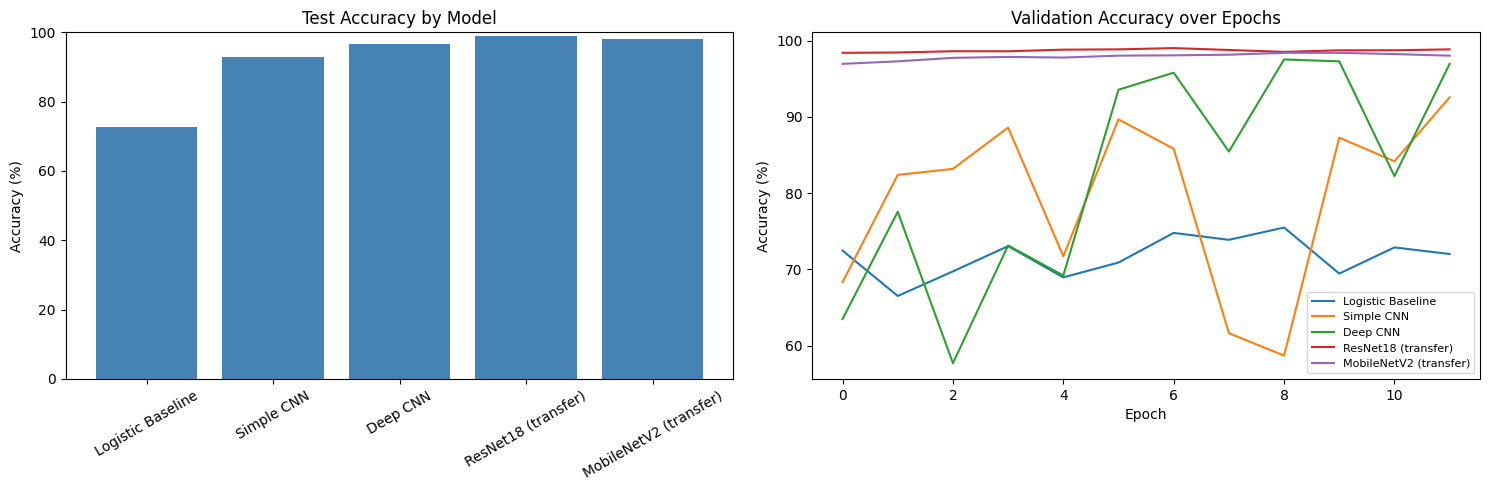

In [14]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart: final test accuracy per model
names = list(results.keys())
test_accs = [results[n]["test_acc"] for n in names]
axs[0].bar(names, test_accs, color="steelblue")
axs[0].set_title("Test Accuracy by Model")
axs[0].set_ylabel("Accuracy (%)")
axs[0].set_ylim([0, 100])
axs[0].tick_params(axis="x", rotation=30)

# Line chart: validation accuracy curve per model
for name, r in results.items():
    axs[1].plot(r["history"]["val_acc"], label=name)
axs[1].set_title("Validation Accuracy over Epochs")
axs[1].set_xlabel("Epoch")
axs[1].set_ylabel("Accuracy (%)")
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

Rough intuition for what you're likely to see: the **Logistic Baseline** should sit well below the rest (no way to learn spatial patterns from a single linear layer over raw pixels). **Simple CNN** vs **Deep CNN** shows whether extra depth actually helps on a dataset this size, or just adds parameters/training time without a real accuracy gain. The two **transfer-learning** models usually reach high accuracy fastest (per epoch) since they start from ImageNet-pretrained features rather than random weights — the trade-off is more parameters "under the hood" (even though most are frozen) and a longer forward pass per batch.


---
# 📋 Cheat Sheet — every function/class used in this notebook

### Data collection & splitting
| Function | Signature | What it does |
|---|---|---|
| `glob.glob(pattern)` | `glob.glob("dir/*/*")` | filesystem paths matching a wildcard pattern |
| `DataFrame.dropna` | `df.dropna()` | drops rows with missing values |
| `train_test_split` | `train_test_split(df, test_size, random_state, stratify)` | splits a DataFrame; `stratify` preserves class proportions |
| `LabelEncoder` | `.fit(labels)` / `.transform([x])` / `.inverse_transform([i])` | string labels ↔ integer indices |

### Image transforms
| Function | What it does |
|---|---|
| `transforms.Compose([...])` | chains transforms into one callable |
| `transforms.Resize((h, w))` | fixed output size |
| `transforms.RandomHorizontalFlip()` | 50% chance left-right flip (augmentation, train only) |
| `transforms.ToTensor()` | PIL image → tensor in `[0, 1]` |
| `transforms.Normalize(mean, std)` | per-channel standardization |

### Data pipeline
| Function | What it does |
|---|---|
| `Dataset.__len__` / `__getitem__` | required methods for any custom `Dataset` |
| `DataLoader(dataset, batch_size, shuffle, num_workers, pin_memory)` | batches/parallelizes data loading |
| `next(iter(loader))` | grabs one batch |

### Building CNNs
| Class | What it does |
|---|---|
| `nn.Conv2d(in, out, kernel_size, padding)` | learnable sliding-window filters |
| `nn.BatchNorm2d(channels)` | normalizes activations per channel; speeds up training |
| `nn.ReLU(inplace=True)` | `max(0, x)`; `inplace=True` saves memory |
| `nn.MaxPool2d(k)` | downsamples by taking the max over `k×k` windows |
| `nn.AdaptiveAvgPool2d(output_size)` | pools to a fixed output size regardless of input resolution |
| `nn.Dropout(p)` | randomly zeroes activations during training (regularization) |
| `nn.Flatten()` | collapses all non-batch dimensions into one |
| `nn.Sequential(*layers)` | chains layers, no custom `forward()` needed |

### Transfer learning
| Function | What it does |
|---|---|
| `resnet18(weights=ResNet18_Weights.DEFAULT)` | loads ResNet-18 with ImageNet-pretrained weights |
| `mobilenet_v2(weights=MobileNet_V2_Weights.DEFAULT)` | loads MobileNetV2 with ImageNet-pretrained weights |
| `param.requires_grad = False` | freezes a parameter — no gradients computed, no updates during training |
| `filter(lambda p: p.requires_grad, model.parameters())` | selects only trainable parameters, e.g. to hand to an optimizer |

### Training & evaluation
| Function | What it does |
|---|---|
| `nn.CrossEntropyLoss()` | multi-class loss; expects raw logits + integer class labels |
| `torch.optim.Adam(params, lr)` | adaptive optimizer |
| `optimizer.zero_grad()` / `loss.backward()` / `optimizer.step()` | the standard gradient update sequence |
| `model.train()` / `model.eval()` | switch training/inference mode |
| `torch.no_grad()` | disables gradient tracking during evaluation |
| `preds.argmax(1)` | predicted class index (highest-scoring logit) per sample |
| `p.numel()` | number of elements in a parameter tensor — summed to count total params |
| `time.time()` | wall-clock timestamp, for timing |

### Comparing results
| Function | What it does |
|---|---|
| `pd.DataFrame(dict).T` | dict-of-dicts → DataFrame, transposed so outer keys become rows |
| `DataFrame.sort_values(col, ascending)` | sort rows by a column's values |
| `plt.subplots(nrows, ncols, figsize)` | grid of subplots |
| `ax.bar(x, height)` | bar chart |
| `ax.tick_params(axis, rotation)` | rotates axis tick labels (handy for long model names) |

---
### 📚 References
- [Animal Faces (AFHQ) dataset — Kaggle](https://www.kaggle.com/datasets/andrewmvd/animal-faces)
- [torchvision.models — pretrained model zoo](https://docs.pytorch.org/vision/stable/models.html)
- [PyTorch documentation (v2.13)](https://docs.pytorch.org/docs/2.13/index.html)
- [01. PyTorch Workflow Fundamentals — learnpytorch.io](https://www.learnpytorch.io/01_pytorch_workflow/)
- [02. PyTorch Neural Network Classification — learnpytorch.io](https://www.learnpytorch.io/02_pytorch_classification/)
